In [39]:
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, PauliGate
import numpy as np 
A = np.array([[ 1.5 , -0.25,  0.  ,  0.  ],
              [-0.25,  1.5 , -0.25,  0.  ],
              [ 0.  , -0.25,  1.5 , -0.25],
              [ 0.  ,  0.  , -0.25,  1.5 ]])
pauli_op = SparsePauliOp.from_operator(A)
pauli_op

SparsePauliOp(['II', 'IX', 'XX', 'YY'],
              coeffs=[ 1.5  +0.j, -0.25 +0.j, -0.125+0.j, -0.125+0.j])

In [42]:
# convert |0>^k -----> Sum( c_i|i>) 
# U∣0⟩=k∑​ak​∣k⟩
n_ancilla = int(np.ceil(np.log2(len(pauli_op.coeffs))))
n_reg = np.log2(len(A))
amps = np.array(pauli_op.coeffs)
amps = np.sqrt(amps / np.linalg.norm(amps,ord=1))
prep_gate = StatePreparation(amps,label="Prep")


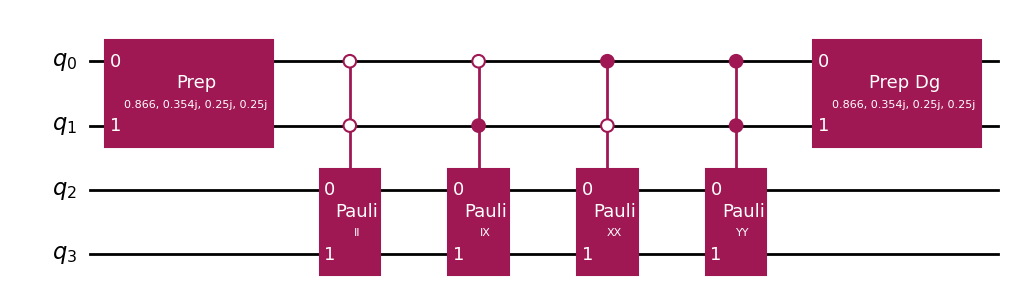

In [43]:
qc  = QuantumCircuit(n_ancilla + n_reg)
qc.append(prep_gate,qc.qubits[:n_ancilla])
for index, pauli in enumerate(pauli_op.paulis):
    intstr = f"{int(index):0{len(qc.qubits[:n_ancilla])}b}"[::-1]
    control_pauli_k = PauliGate(pauli.to_label()).control(num_ctrl_qubits=n_ancilla,ctrl_state=intstr)
    qc.append(control_pauli_k,qc.qubits)
qc.append(prep_gate.inverse(),qc.qubits[:n_ancilla])
qc.draw("mpl")


In [ ]:
def selection_matrix(pauli_op : SparsePauliOp):
    dim = len[pauli_op.coeffs]
    select_matrix = None
    for i in range(dim):
        u_k = pauli_op.paulis[i].to_matrix()
        ket_i = Statevector.from_int(i, dim).data
        outer_product = np.outer(ket_i,ket_i.conj())

        if not select_matrix:
            select_matrix = np.kron(outer_product,u_k)
        else:
            select_matrix = select_matrix + np.kron(outer_product,u_k)
    return select_matrix
